In [29]:
# =========================
# IMPORTS
# =========================
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import StratifiedKFold

# =========================
# LOAD DATA
# =========================
BASE_PATH = "/kaggle/input/datasets/shuvetajovia/babyear4k"
images_path = os.path.join(BASE_PATH, "images")

diagnosis_df = pd.read_csv(os.path.join(BASE_PATH, "diagnosis_result.csv"))
bbox_df = pd.read_csv(os.path.join(BASE_PATH, "bounding.csv"))
quality_df = pd.read_csv(os.path.join(BASE_PATH, "image_quality_assessment.csv"))

df = bbox_df.merge(quality_df, on="image_pathname")

df = df.rename(columns={
    "image_pathname": "image",
    "left_bound": "xmin",
    "top_bound": "ymin",
    "right_bound": "xmax",
    "bottom_bound": "ymax",
    "total_score": "quality_score"
})

df["file"] = df["image"].apply(lambda x: x.split("/")[-1])
df["baby_id"] = df["file"].apply(lambda x: x.split("_")[0])
df["side"] = df["file"].apply(lambda x: "L" if "_L" in x else "R")

df["baby_id"] = df["baby_id"].astype(str)
diagnosis_df["baby_id"] = diagnosis_df["baby_id"].astype(str)

df = df.merge(diagnosis_df, on="baby_id")

def is_abnormal(val):
    return 0 if str(val) == "0+0+0" else 1

df["label"] = df.apply(
    lambda row: is_abnormal(row["L_merge"]) if row["side"]=="L"
    else is_abnormal(row["R_merge"]),
    axis=1
)

print("Label Distribution:\n", df["label"].value_counts())

# =========================
# DATASET
# =========================
class EarDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(os.path.join(self.img_dir, row["file"])).convert("RGB")

        xmin, ymin = int(row["xmin"]), int(row["ymin"])
        xmax, ymax = int(row["xmax"]), int(row["ymax"])

        # ROI IMPROVEMENT
        pad = 20
        xmin = max(0, xmin - pad)
        ymin = max(0, ymin - pad)
        xmax = min(img.size[0], xmax + pad)
        ymax = min(img.size[1], ymax + pad)

        img = img.crop((xmin, ymin, xmax, ymax))
        img = self.transform(img)

        return img, torch.tensor(row["label"], dtype=torch.long)

# =========================
# TRANSFORMS
# =========================
train_tf = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3,0.2),
    transforms.ToTensor(),
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

# =========================
# CLASS WEIGHTS (FIX ADDED)
# =========================
class_counts = df["label"].value_counts()
weights = torch.tensor([1.0/class_counts[0], 1.0/class_counts[1]])
weights = weights.float()   # 🔥 FIX

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# K-FOLD
# =========================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df, df["label"])):

    print(f"\n Fold {fold+1}")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_loader = DataLoader(EarDataset(train_df, images_path, train_tf), batch_size=32, shuffle=True)
    val_loader = DataLoader(EarDataset(val_df, images_path, val_tf), batch_size=32)

    #  CHANGE MODEL HERE
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=2)
    # model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
    # model = timm.create_model('deit_base_patch16_224', pretrained=True, num_classes=2)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    # =========================
    # TRAIN
    # =========================
    for epoch in range(10):
        model.train()

        for img, label in train_loader:
            img, label = img.to(device), label.to(device)

            loss = criterion(model(img), label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        scheduler.step()

    # =========================
    # TTA VALIDATION
    # =========================
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for img, label in val_loader:
            img, label = img.to(device), label.to(device)

            outputs = []
            for _ in range(7):
                aug = img.clone()
                if torch.rand(1) > 0.5:
                    aug = torch.flip(aug, dims=[3])
                outputs.append(model(aug))

            preds = torch.stack(outputs).mean(0).argmax(1)

            total += label.size(0)
            correct += (preds == label).sum().item()

    acc = 100 * correct / total
    print(f"Fold {fold+1} Accuracy: {acc:.2f}%")

    # SAVE MODEL
    torch.save(model.state_dict(), f"/kaggle/working/model_fold_{fold+1}.pth")

    accuracies.append(acc)

# =========================
# FINAL RESULT
# =========================
final_acc = sum(accuracies) / len(accuracies)

print(f"\n FINAL AVG ACCURACY: {final_acc:.2f}%")

with open("/kaggle/working/final_result.txt", "w") as f:
    f.write(f"Final Accuracy: {final_acc:.2f}%")

Label Distribution:
 label
0    1087
1     863
Name: count, dtype: int64

 Fold 1
Fold 1 Accuracy: 79.74%

 Fold 2
Fold 2 Accuracy: 80.00%

 Fold 3
Fold 3 Accuracy: 77.95%

 Fold 4
Fold 4 Accuracy: 79.49%

 Fold 5
Fold 5 Accuracy: 75.13%

 FINAL AVG ACCURACY: 78.46%


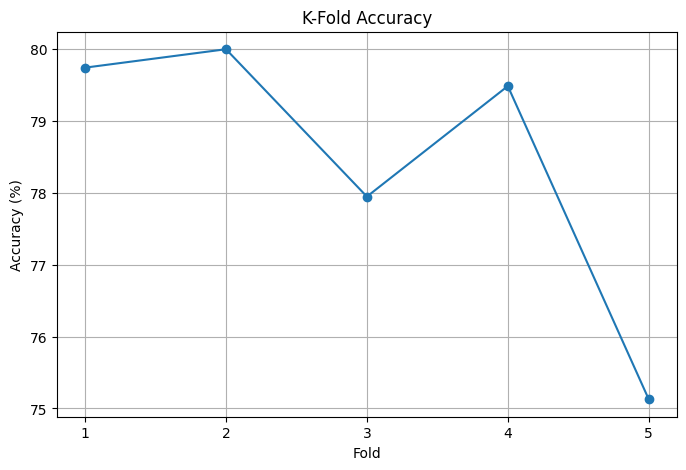

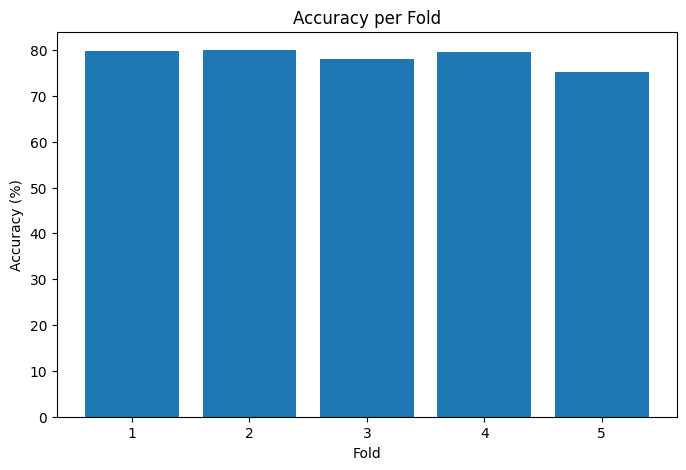

📊 RESULTS SUMMARY
-------------------------
Fold Accuracies: [79.74358974358974, 80.0, 77.94871794871794, 79.48717948717949, 75.12820512820512]
Mean Accuracy: 78.46%
Max Accuracy: 80.00%
Min Accuracy: 75.13%
Std Deviation: 1.81
✅ Graph saved as accuracy_graph.png


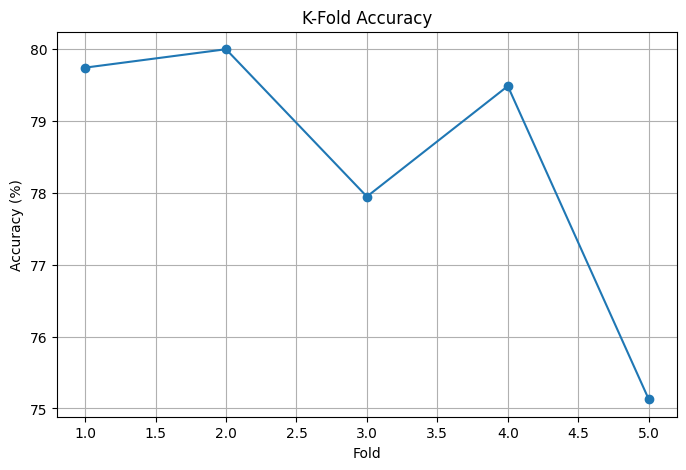

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. FOLD ACCURACY GRAPH
# =========================
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracies)+1), accuracies, marker='o')
plt.title("K-Fold Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.xticks(range(1, len(accuracies)+1))
plt.grid()

plt.show()

# =========================
# 2. BAR GRAPH (BETTER FOR PPT)
# =========================
plt.figure(figsize=(8,5))
plt.bar(range(1, len(accuracies)+1), accuracies)
plt.title("Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")

plt.show()

# =========================
# 3. FINAL METRICS
# =========================
acc_array = np.array(accuracies)

print("📊 RESULTS SUMMARY")
print("-------------------------")
print(f"Fold Accuracies: {accuracies}")
print(f"Mean Accuracy: {acc_array.mean():.2f}%")
print(f"Max Accuracy: {acc_array.max():.2f}%")
print(f"Min Accuracy: {acc_array.min():.2f}%")
print(f"Std Deviation: {acc_array.std():.2f}")

# =========================
# 4. SAVE GRAPH (IMPORTANT)
# =========================
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accuracies)+1), accuracies, marker='o')
plt.title("K-Fold Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.grid()

plt.savefig("/kaggle/working/accuracy_graph.png")

print("✅ Graph saved as accuracy_graph.png")